# Financial Benchmarking of Software and Related Technology Firms Using WRDS Compustat Data

## Project Overview

This notebook develops a simple benchmarking tool for comparing the financial performance of software and related technology service firms using WRDS Compustat annual data. The analysis focuses on firms with historical SIC codes from 7370 to 7379, which broadly represent software and related technology services.

## Product Purpose

The purpose of this notebook is to build a reusable Python workflow and a simple interactive benchmarking tool that helps users examine industry-wide performance patterns, track changes over time, and compare an individual firm with the broader industry benchmark.

## Research Question

How has the financial performance of software and related technology service firms changed from 2015 to 2024, and how does an individual firm compare with the overall industry benchmark?

## Intended Users

This notebook is designed for business students and beginner investors who want a simple benchmarking tool to compare a selected firm’s financial performance with the broader industry benchmark.

## Data Source

The data are retrieved from WRDS Compustat Annual Fundamentals (`comp.funda`), which provides firm-level annual accounting data such as net income, total assets, sales, and total equity. Python is used throughout the project for data retrieval, cleaning, transformation, analysis, and visualisation.

## Financial Performance Measures

The analysis uses eight accounting-based indicators: Return on Assets (ROA), Return on Equity (ROE), Profit Margin, Turnover, Leverage, Equity Ratio, Revenue Growth, and Asset Growth. These measures capture different aspects of firm performance, including profitability, efficiency, capital structure, and growth.

## Workflow Overview

The notebook follows five main stages:

1. retrieve and prepare annual firm-level data from WRDS Compustat  
2. construct profitability and growth measures  
3. reduce the influence of extreme values using winsorization  
4. summarise industry-level patterns over time  
5. compare a selected firm with the industry benchmark using tables and charts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

db = wrds.Connection()

## Variable Selection

Before extracting the final sample, the notebook checks the structure of `comp.funda` and selects the key variables needed for firm identification, sample filtering, and profitability analysis.

The analysis uses the following variables:

- `gvkey`: firm identifier  
- `datadate`: reporting date  
- `fyear`: fiscal year  
- `tic`: ticker symbol  
- `conm`: company name  
- `sich`: historical SIC code  
- `ni`: net profit  
- `at`: total assets  
- `sale`: total revenue  
- `seq`: total equity  
- `indfmt`, `datafmt`, `popsrc`, `consol`: standard Compustat filters  

These standard Compustat filters are used to keep the sample consistent by focusing on industrial-format, standard, domestic, and consolidated annual statements.

In [2]:
funda_cols = db.describe_table(library='comp', table='funda')

selected_cols = funda_cols[
    funda_cols['name'].isin([
        'gvkey', 'datadate', 'fyear', 'tic', 'conm', 'sich',
        'ni', 'at', 'sale', 'seq',
        'indfmt', 'datafmt', 'popsrc', 'consol'
    ])
]

selected_cols

Approximately 937948 rows in comp.funda.


,name,nullable,type,comment
0,gvkey,True,VARCHAR(7),Global Company Key
1,datadate,True,DATE,Data Date
2,fyear,True,INTEGER,Data Year - Fiscal
3,indfmt,True,VARCHAR(13),Industry Format
4,consol,True,VARCHAR(3),Level of Consolidation - Company Annual Descri...
5,popsrc,True,VARCHAR(2),Population Source
6,datafmt,True,VARCHAR(13),Data Format
7,tic,True,VARCHAR(8),Ticker Symbol
9,conm,True,VARCHAR(70),Company Name
94,at,True,"NUMERIC(18, 4)",Assets - Total


## Data Retrieval

The project retrieves annual firm-level financial data from WRDS Compustat (`comp.funda`). To keep the industry definition clear and manageable, the sample focuses on firms with historical SIC codes (`sich`) between 7370 and 7379, which broadly represent software and related technology services.

The extracted dataset includes the variables required for firm identification and multi-metric profitability analysis, including net income, total assets, revenue, and total equity.

In [3]:
# Parameters
pull_start_year = 2014      # pull one extra year for lag-based growth metrics
analysis_start_year = 2015
analysis_end_year = 2024

sich_low = 7370
sich_high = 7379

query = f"""
SELECT gvkey, datadate, fyear, tic, conm,
       at, ni, sale, seq, sich,
       indfmt, datafmt, popsrc, consol
FROM comp.funda
WHERE fyear BETWEEN {pull_start_year} AND {analysis_end_year}
  AND sich BETWEEN {sich_low} AND {sich_high}
  AND at IS NOT NULL
  AND ni IS NOT NULL
  AND sale IS NOT NULL
  AND seq IS NOT NULL
  AND indfmt = 'INDL'
  AND datafmt = 'STD'
  AND popsrc = 'D'
  AND consol = 'C'
"""

tech_data = db.raw_sql(query)
tech_data.head()

,gvkey,datadate,fyear,tic,conm,at,ni,sale,seq,sich,indfmt,datafmt,popsrc,consol
0,001084,2014-12-31,2014,WDDD,WORLDS INC,0.028,-0.983,0.0,-4.604,7370,INDL,STD,D,C
1,001562,2015-04-30,2014,LGTY,LOGILITY SPPLY CHAIN SOL INC,134.266,8.128,102.873,92.926,7372,INDL,STD,D,C
2,001878,2015-01-31,2014,ADSK,AUTODESK INC,4913.8,81.8,2512.2,2219.2,7372,INDL,STD,D,C
3,001891,2014-06-30,2014,ADP,AUTOMATIC DATA PROCESSING,32051.7,1515.9,12206.5,6670.2,7374,INDL,STD,D,C
4,002504,2014-12-31,2014,UIS,UNISYS CORP,2348.7,46.7,3356.4,-1460.0,7373,INDL,STD,D,C


## Initial Data Checks

After extracting the data from WRDS, this section checks the size and coverage of the initial sample. It also confirms that each firm-year observation is unique based on `gvkey` and `fyear`.

In [4]:
tech_data.shape

(7096, 14)

In [5]:
analysis_data = tech_data.copy()

analysis_data = analysis_data.rename(columns={
    'conm': 'company_name',
    'tic': 'ticker',
    'ni': 'net_income',
    'at': 'total_assets',
    'sale': 'revenue',
    'seq': 'total_equity',
    'sich': 'industry_code'
})

In [6]:
analysis_data['datadate'] = pd.to_datetime(analysis_data['datadate'])

print("Firm-year observations:", len(analysis_data))
print("Unique firms:", analysis_data['gvkey'].nunique())
print("Year range:", analysis_data['fyear'].min(), "-", analysis_data['fyear'].max())
print("Number of tickers:", analysis_data['ticker'].nunique())

Firm-year observations: 7096
Unique firms: 1283
Year range: 2014 - 2024
Number of tickers: 1283


In [7]:
print("Duplicate firm-year observations:", analysis_data[['gvkey', 'fyear']].duplicated().sum())

Duplicate firm-year observations: 0


## Data Cleaning and Preparation

This section prepares the working dataset for analysis. Since the sample structure and variable names were already checked in the previous section, the focus here is on reviewing data types, checking missing values in key financial variables, and confirming that the dataset is ready for the construction of profitability measures.

In [8]:
analysis_data.dtypes

gvkey            string[python]
datadate         datetime64[ns]
fyear                     Int64
ticker           string[python]
company_name     string[python]
total_assets            Float64
net_income              Float64
revenue                 Float64
total_equity            Float64
industry_code             Int64
indfmt           string[python]
datafmt          string[python]
popsrc           string[python]
consol           string[python]
dtype: object

In [9]:
analysis_data[['net_income', 'total_assets', 'revenue', 'total_equity']].isnull().sum()

net_income      0
total_assets    0
revenue         0
total_equity    0
dtype: int64

## Financial Performance Measures

This project uses eight financial indicators to evaluate firm performance in the selected industry sample:

- **Return on Assets (ROA)** = net profit / total assets  
- **Return on Equity (ROE)** = net profit / total equity  
- **Profit Margin** = net income / revenue  
- **Turnover** = revenue / total assets  
- **Leverage** = total assets / total equity  
- **Equity Ratio** = total equity / total assets  
- **Revenue Growth** = current revenue / lagged revenue - 1  
- **Asset Growth** = current total assets / lagged total assets - 1  

These measures capture different aspects of firm performance. Profitability ratios show earnings relative to assets, equity, and sales; turnover reflects operating efficiency; leverage and equity ratio describe capital structure; and the growth measures capture expansion over time.

In [10]:
# Make sure numeric columns are standard float, not nullable Float64
numeric_cols = ['net_income', 'total_assets', 'revenue', 'total_equity']
analysis_data[numeric_cols] = analysis_data[numeric_cols].astype('float64')

# Sort before constructing lag-based metrics
analysis_data = analysis_data.sort_values(['gvkey', 'fyear']).copy()

# Initialize new columns
analysis_data['roa'] = np.nan
analysis_data['profit_margin'] = np.nan
analysis_data['turnover'] = np.nan
analysis_data['leverage'] = np.nan
analysis_data['roe'] = np.nan
analysis_data['equity_ratio'] = np.nan

# Core ratios
mask_assets = analysis_data['total_assets'].notna() & (analysis_data['total_assets'] > 0)
mask_revenue = analysis_data['revenue'].notna() & (analysis_data['revenue'] > 0)
mask_equity = analysis_data['total_equity'].notna() & (analysis_data['total_equity'] > 0)

analysis_data.loc[mask_assets, 'roa'] = (
    analysis_data.loc[mask_assets, 'net_income'] /
    analysis_data.loc[mask_assets, 'total_assets']
)

analysis_data.loc[mask_revenue, 'profit_margin'] = (
    analysis_data.loc[mask_revenue, 'net_income'] /
    analysis_data.loc[mask_revenue, 'revenue']
)

analysis_data.loc[mask_assets, 'turnover'] = (
    analysis_data.loc[mask_assets, 'revenue'] /
    analysis_data.loc[mask_assets, 'total_assets']
)

analysis_data.loc[mask_equity, 'leverage'] = (
    analysis_data.loc[mask_equity, 'total_assets'] /
    analysis_data.loc[mask_equity, 'total_equity']
)

analysis_data.loc[mask_equity, 'roe'] = (
    analysis_data.loc[mask_equity, 'net_income'] /
    analysis_data.loc[mask_equity, 'total_equity']
)

analysis_data.loc[mask_assets, 'equity_ratio'] = (
    analysis_data.loc[mask_assets, 'total_equity'] /
    analysis_data.loc[mask_assets, 'total_assets']
)

# Lag variables for growth metrics
analysis_data['lag_revenue'] = analysis_data.groupby('gvkey')['revenue'].shift(1)
analysis_data['lag_assets'] = analysis_data.groupby('gvkey')['total_assets'].shift(1)

analysis_data['revenue_growth'] = np.nan
analysis_data['asset_growth'] = np.nan

mask_lag_revenue = analysis_data['lag_revenue'].notna() & (analysis_data['lag_revenue'] > 0)
mask_lag_assets = analysis_data['lag_assets'].notna() & (analysis_data['lag_assets'] > 0)

analysis_data.loc[mask_lag_revenue, 'revenue_growth'] = (
    analysis_data.loc[mask_lag_revenue, 'revenue'] /
    analysis_data.loc[mask_lag_revenue, 'lag_revenue'] - 1
)

analysis_data.loc[mask_lag_assets, 'asset_growth'] = (
    analysis_data.loc[mask_lag_assets, 'total_assets'] /
    analysis_data.loc[mask_lag_assets, 'lag_assets'] - 1
)

# Keep analysis period only
analysis_data = analysis_data[
    (analysis_data['fyear'] >= analysis_start_year) &
    (analysis_data['fyear'] <= analysis_end_year)
].copy()

# Drop temporary lag columns
analysis_data = analysis_data.drop(columns=['lag_revenue', 'lag_assets'])

# Check missing values
metric_cols = [
    'roa', 'roe', 'profit_margin', 'turnover',
    'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth'
]

analysis_data[metric_cols].isnull().sum()

roa                 29
roe               1084
profit_margin      236
turnover            29
leverage          1084
equity_ratio        29
revenue_growth     836
asset_growth       667
dtype: int64

In [11]:
analysis_data[['roa', 'roe', 'profit_margin', 'turnover',
     'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth']
].isnull().sum()

roa                 29
roe               1084
profit_margin      236
turnover            29
leverage          1084
equity_ratio        29
revenue_growth     836
asset_growth       667
dtype: int64

In [12]:
analysis_data[
    ['roa', 'roe', 'profit_margin', 'turnover',
     'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth']
].describe()

,roa,roe,profit_margin,turnover,leverage,equity_ratio,revenue_growth,asset_growth
count,6429.000000,5374.000000,6222.000000,6429.000000,5374.000000,6429.000000,5622.000000,5791.000000
mean,-3.324657,-0.725774,-14.116744,0.838937,8.679769,-4.028361,1.074064,27.427302
std,49.605635,11.632892,223.854279,2.461310,295.910026,58.815073,22.626106,1971.848121
min,-2300.500000,-647.596859,-8405.000000,0.000000,0.309388,-2452.500000,-1.000000,-1.000000
25%,-0.270395,-0.386704,-0.394008,0.340417,1.427316,0.180249,-0.005038,-0.063138
50%,-0.047096,-0.048027,-0.069812,0.580771,1.911302,0.453071,0.122133,0.061557
75%,0.043177,0.104669,0.070822,0.936723,2.998689,0.666734,0.306267,0.306609
max,178.800000,388.700000,1357.416667,155.828571,21431.714286,3.232183,1155.857143,150021.000000


In [13]:
analysis_data[
    ['roa', 'roe', 'profit_margin', 'turnover',
     'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth']
].quantile([0.01, 0.05, 0.95, 0.99])

,roa,roe,profit_margin,turnover,leverage,equity_ratio,revenue_growth,asset_growth
0.01,-38.423117,-11.825604,-185.961288,0.000000,1.048378,-61.975723,-0.947689,-0.863890
0.05,-2.831756,-2.565188,-7.746416,0.023433,1.132563,-3.124815,-0.387615,-0.455993
0.95,0.172955,0.398905,0.275075,2.126333,9.259330,0.871751,1.103681,2.066996
0.99,0.406406,1.061377,0.668916,4.502125,43.005475,0.945664,7.208985,9.302458


## Outlier Treatment

The summary statistics suggest that several financial ratios contain extreme values. This is common in accounting data because some firms have very small denominators, such as assets, sales, or equity, which can produce unusually large ratios.

To reduce the influence of extreme observations while preserving sample size, this project applies winsorization at the 1st and 99th percentiles for each metric. Unlike trimming, winsorization caps extreme values rather than removing them, which helps stabilise later summaries and charts without creating additional missing values.

In [14]:
winsorized_data = analysis_data.copy()

winsor_metrics = [
    'roa', 'roe', 'profit_margin', 'turnover',
    'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth'
]

winsor_bounds = {}

for col in winsor_metrics:
    lower = winsorized_data[col].quantile(0.01)
    upper = winsorized_data[col].quantile(0.99)
    
    winsor_bounds[col] = {'p1': lower, 'p99': upper}
    
    winsorized_data[col] = winsorized_data[col].clip(lower=lower, upper=upper)

pd.DataFrame(winsor_bounds).T

,p1,p99
roa,-38.423117,0.406406
roe,-11.825604,1.061377
profit_margin,-185.961288,0.668916
turnover,0.000000,4.502125
leverage,1.048378,43.005475
equity_ratio,-61.975723,0.945664
revenue_growth,-0.947689,7.208985
asset_growth,-0.863890,9.302458


In [15]:
winsorized_data[winsor_metrics].describe()

,roa,roe,profit_margin,turnover,leverage,equity_ratio,revenue_growth,asset_growth
count,6429.000000,5374.000000,6222.000000,6429.000000,5374.000000,6429.000000,5622.000000,5791.000000
mean,-0.970874,-0.479756,-3.773638,0.766872,3.367876,-0.878529,0.282300,0.377410
std,4.609379,1.653325,21.600904,0.739192,5.330129,7.398847,0.939157,1.296677
min,-38.423117,-11.825604,-185.961288,0.000000,1.048378,-61.975723,-0.947689,-0.863890
25%,-0.270395,-0.386704,-0.394008,0.340417,1.427316,0.180249,-0.005038,-0.063138
50%,-0.047096,-0.048027,-0.069812,0.580771,1.911302,0.453071,0.122133,0.061557
75%,0.043177,0.104669,0.070822,0.936723,2.998689,0.666734,0.306267,0.306609
max,0.406406,1.061377,0.668916,4.502125,43.005475,0.945664,7.208985,9.302458


In [16]:
winsorized_data[winsor_metrics].isnull().sum()

roa                 29
roe               1084
profit_margin      236
turnover            29
leverage          1084
equity_ratio        29
revenue_growth     836
asset_growth       667
dtype: int64

## Balanced Sample Screening

The project uses two related analysis samples. First, industry-level trend and distribution charts are based on the full cleaned and winsorized sample. Second, long-horizon firm benchmarking uses a stricter balanced sample that requires complete observations for the core metrics (ROA, Profit Margin, and Turnover) in every fiscal year from 2015 to 2024.

Leverage, ROE, growth measures, and other supplementary indicators are reported when available, but they are not used as hard screening requirements. This design improves comparability for company benchmarking while avoiding excessive sample loss.

In [17]:
required_years = list(range(analysis_start_year, analysis_end_year + 1))

# full sample for industry-level charts
full_sample = winsorized_data[
    winsorized_data['fyear'].isin(required_years)
].copy()

# core metrics only for balanced benchmarking
core_metrics = ['roa', 'profit_margin', 'turnover']

complete_firm_years = (
    full_sample
    .dropna(subset=core_metrics)
    .groupby('gvkey')['fyear']
    .nunique()
)

valid_gvkeys = complete_firm_years[
    complete_firm_years == len(required_years)
].index

balanced_data = full_sample[
    full_sample['gvkey'].isin(valid_gvkeys)
].copy()

print("Number of firms in full sample:", full_sample['gvkey'].nunique())
print("Number of firms in balanced benchmark sample:", balanced_data['gvkey'].nunique())
print("Number of firm-year observations in balanced benchmark sample:", len(balanced_data))

Number of firms in full sample: 1208
Number of firms in balanced benchmark sample: 214
Number of firm-year observations in balanced benchmark sample: 2140


In [18]:
balanced_data[
    ['roa', 'roe', 'profit_margin', 'turnover',
     'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth']
].isnull().sum()

roa                 0
roe               211
profit_margin       0
turnover            0
leverage          211
equity_ratio        0
revenue_growth     18
asset_growth       18
dtype: int64

## Yearly Summary of Profitability Metrics

After winsorization, the notebook summarises each metric by fiscal year using the industry mean, median, and valid observation count. These yearly summaries are based on the full cleaned sample rather than the balanced benchmark sample, so that industry-level patterns reflect as much available information as possible.

The balanced sample is reserved for long-horizon company benchmarking only.

In [19]:
trend_metrics = [
    'roa', 'roe', 'profit_margin', 'turnover',
    'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth'
]

metric_yearly_summary = {}

for col in trend_metrics:
    summary = (
        full_sample.groupby('fyear')[col]
        .agg(['mean', 'median', 'count'])
        .reset_index()
        .rename(columns={
            'mean': f'{col}_mean',
            'median': f'{col}_median',
            'count': f'{col}_count'
        })
    )
    metric_yearly_summary[col] = summary

yearly_summary_all = metric_yearly_summary['roa'].copy()

for col in trend_metrics[1:]:
    yearly_summary_all = yearly_summary_all.merge(
        metric_yearly_summary[col],
        on='fyear',
        how='outer'
    )

yearly_summary_all.round(4)

,fyear,roa_mean,roa_median,roa_count,roe_mean,roe_median,roe_count,profit_margin_mean,profit_margin_median,profit_margin_count,...,leverage_count,equity_ratio_mean,equity_ratio_median,equity_ratio_count,revenue_growth_mean,revenue_growth_median,revenue_growth_count,asset_growth_mean,asset_growth_median,asset_growth_count
0,2015,-1.4945,-0.0504,605,-0.5213,-0.0266,494,-4.1293,-0.0555,575,...,494,-1.4983,0.4500,605,0.2764,0.1106,538,0.3115,0.0468,559
1,2016,-1.4477,-0.0507,589,-0.4221,-0.0214,470,-2.9992,-0.0489,563,...,470,-1.4085,0.4031,589,0.2012,0.0950,501,0.1981,0.0298,521
2,2017,-1.3780,-0.0339,584,-0.5010,-0.0146,479,-4.0507,-0.0414,559,...,479,-1.6127,0.4233,584,0.3724,0.1391,503,0.4916,0.1066,525
3,2018,-1.2574,-0.0220,589,-0.3975,-0.0015,499,-3.8422,-0.0263,572,...,499,-1.0535,0.4448,589,0.3044,0.1372,513,0.3557,0.0677,532
4,2019,-0.6999,-0.0470,650,-0.4433,-0.0548,549,-3.4842,-0.0749,631,...,549,-0.8069,0.4170,650,0.3218,0.1394,529,0.5294,0.1579,542
5,2020,-0.6657,-0.0380,687,-0.4127,-0.0498,582,-1.7734,-0.0770,664,...,582,-0.5967,0.4333,687,0.2918,0.1375,595,0.6097,0.1584,614
6,2021,-0.7062,-0.0447,715,-0.3899,-0.0602,627,-4.6936,-0.0834,694,...,627,-0.4843,0.5034,715,0.4312,0.2102,625,0.7687,0.1698,645
7,2022,-0.7890,-0.0940,703,-0.7031,-0.1293,596,-3.9167,-0.1668,690,...,596,-0.5759,0.4788,703,0.3022,0.1320,617,0.1242,-0.0174,635
8,2023,-0.7800,-0.0661,664,-0.5396,-0.0686,553,-4.1984,-0.1044,652,...,553,-0.4735,0.4646,664,0.2007,0.0830,601,0.1242,-0.0022,607
9,2024,-0.6995,-0.0402,643,-0.4543,-0.0254,525,-4.6322,-0.0506,622,...,525,-0.5438,0.4708,643,0.1228,0.0666,600,0.2448,0.0217,611


## Industry Benchmark Table

This section prepares a compact industry benchmark table for later use in visualisations and company-level benchmarking. For each fiscal year, it keeps the industry mean and median for every metric so that firm-level comparisons can be made more robustly

In [20]:
industry_benchmark = metric_yearly_summary['roa'][['fyear', 'roa_mean', 'roa_median']].copy()

for metric in trend_metrics[1:]:
    industry_benchmark = industry_benchmark.merge(
        metric_yearly_summary[metric][['fyear', f'{metric}_mean', f'{metric}_median']],
        on='fyear',
        how='outer'
    )

industry_benchmark = industry_benchmark.sort_values('fyear').reset_index(drop=True)

print("Industry benchmark table created successfully.")

Industry benchmark table created successfully.


## Industry-Level Trends Over Time

This section visualises how the industry benchmark changes over time. The charts compare yearly industry means and medians across the selected profitability, capital structure, and growth measures, helping users identify broad shifts in performance between 2015 and 2024.

Additional boxplots and latest-year benchmark charts are included to show how firm performance distributions evolve across years and how the most recent benchmark differs across metrics.

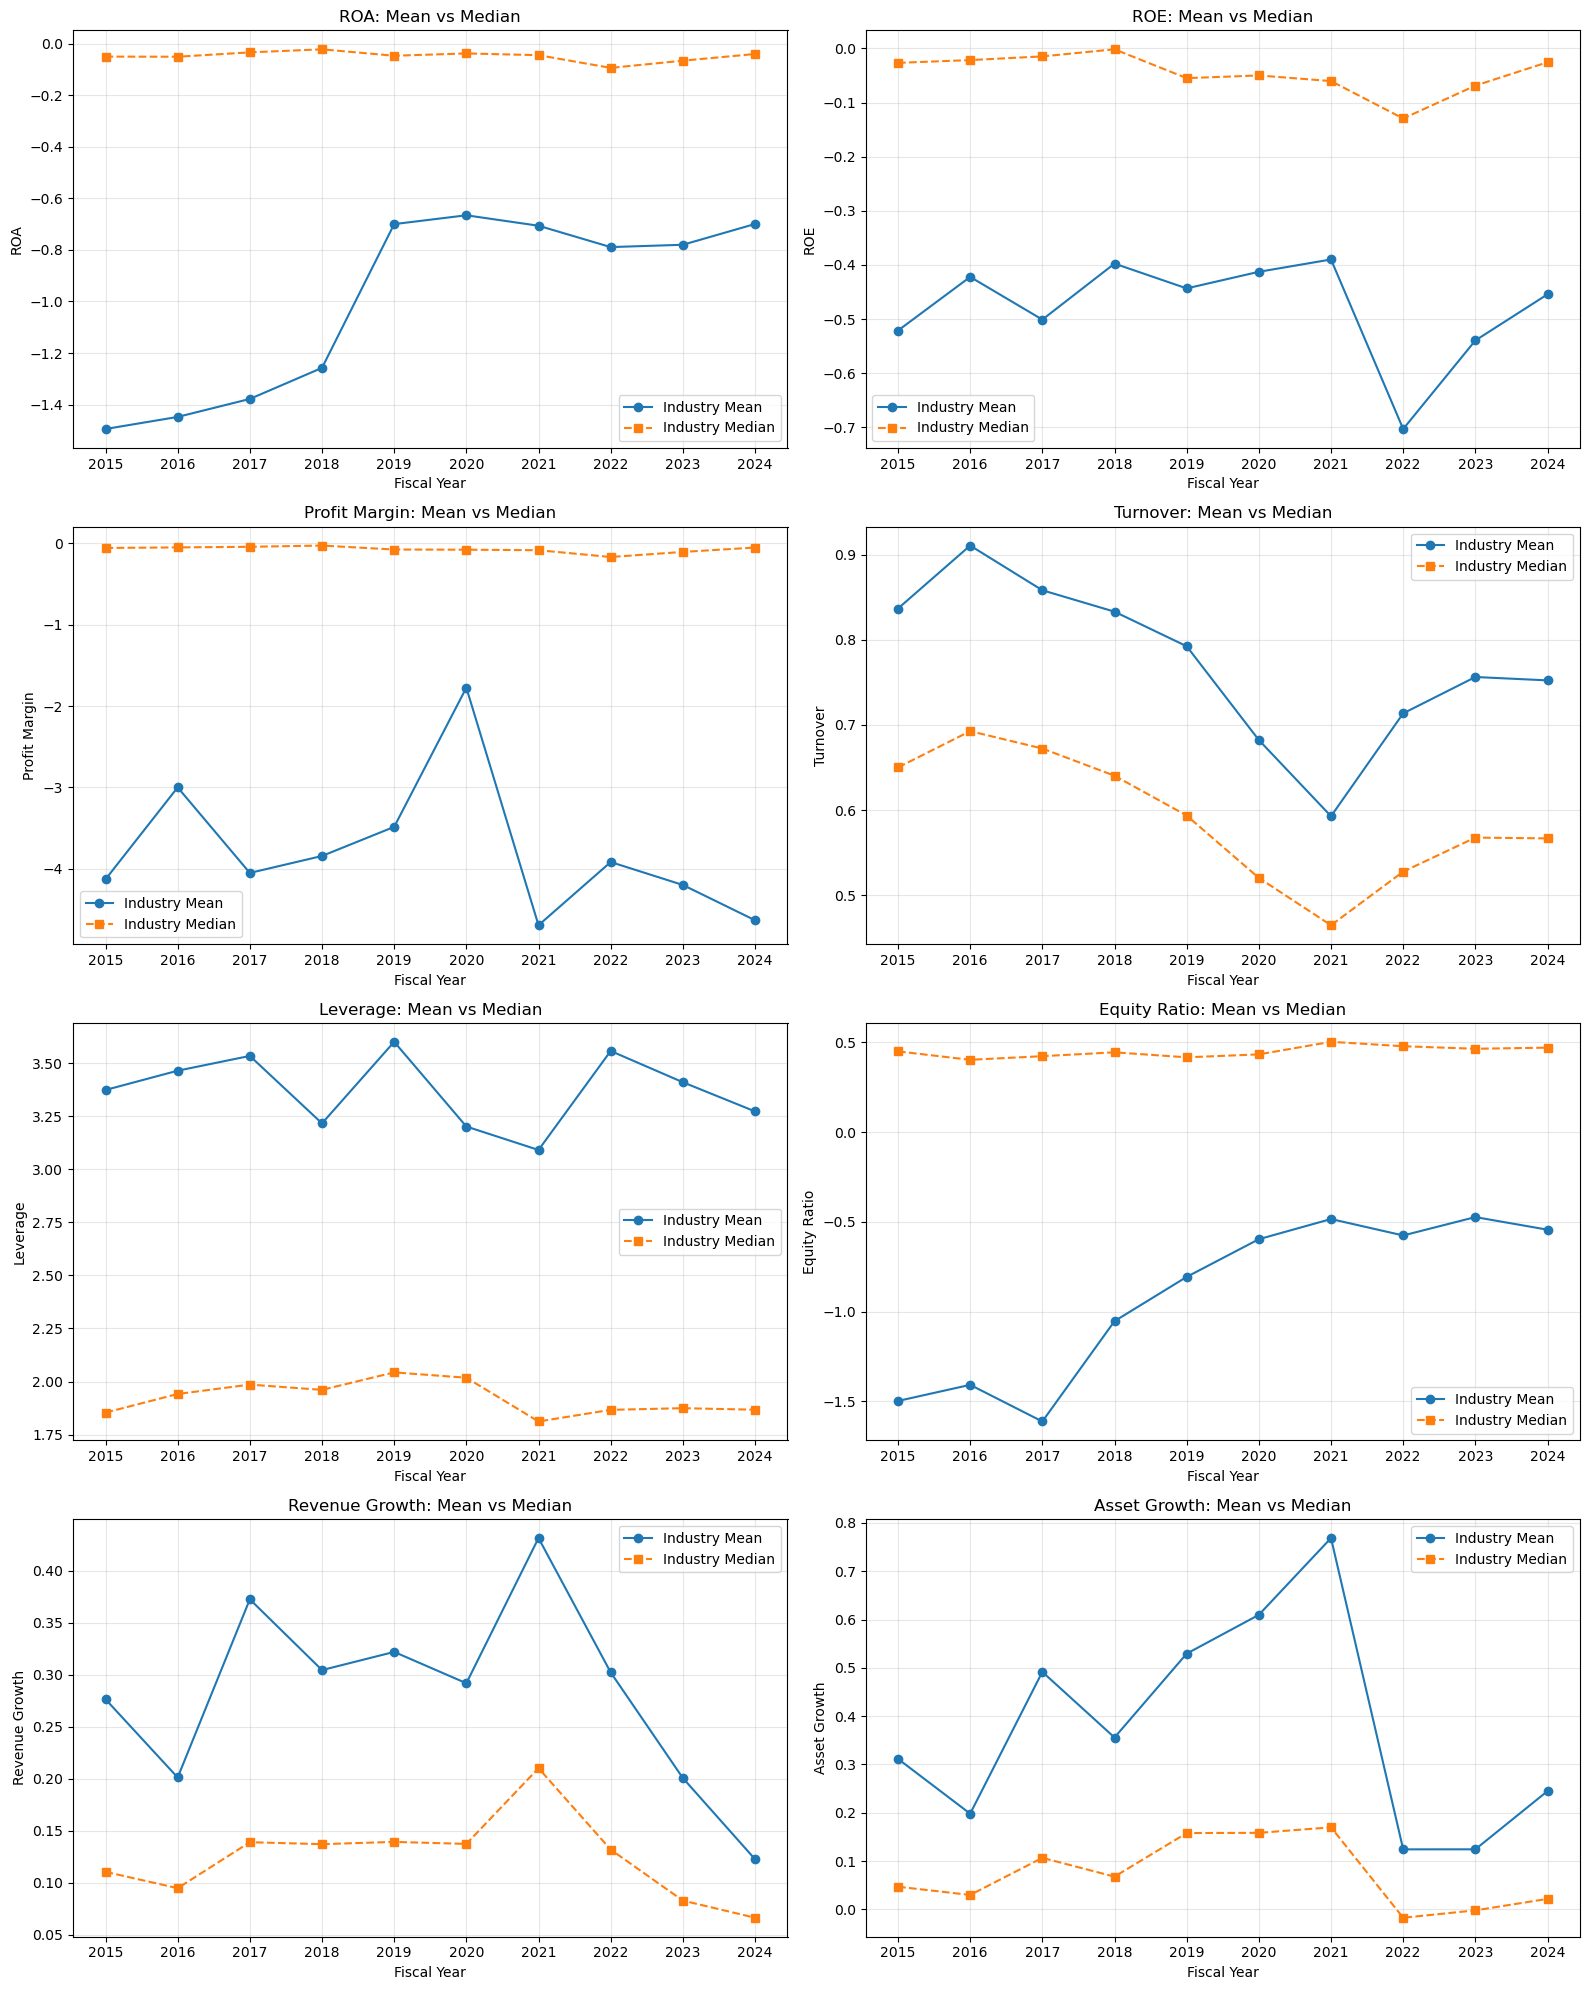

In [21]:
titles = {
    'roa': 'ROA',
    'roe': 'ROE',
    'profit_margin': 'Profit Margin',
    'turnover': 'Turnover',
    'leverage': 'Leverage',
    'equity_ratio': 'Equity Ratio',
    'revenue_growth': 'Revenue Growth',
    'asset_growth': 'Asset Growth'
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, metric in zip(axes, trend_metrics):
    temp = metric_yearly_summary[metric]
    
    ax.plot(temp['fyear'], temp[f'{metric}_mean'], marker='o', label='Industry Mean')
    ax.plot(temp['fyear'], temp[f'{metric}_median'], marker='s', linestyle='--', label='Industry Median')
    
    ax.set_title(f"{titles[metric]}: Mean vs Median")
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel(titles[metric])
    ax.set_xticks(temp['fyear'])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

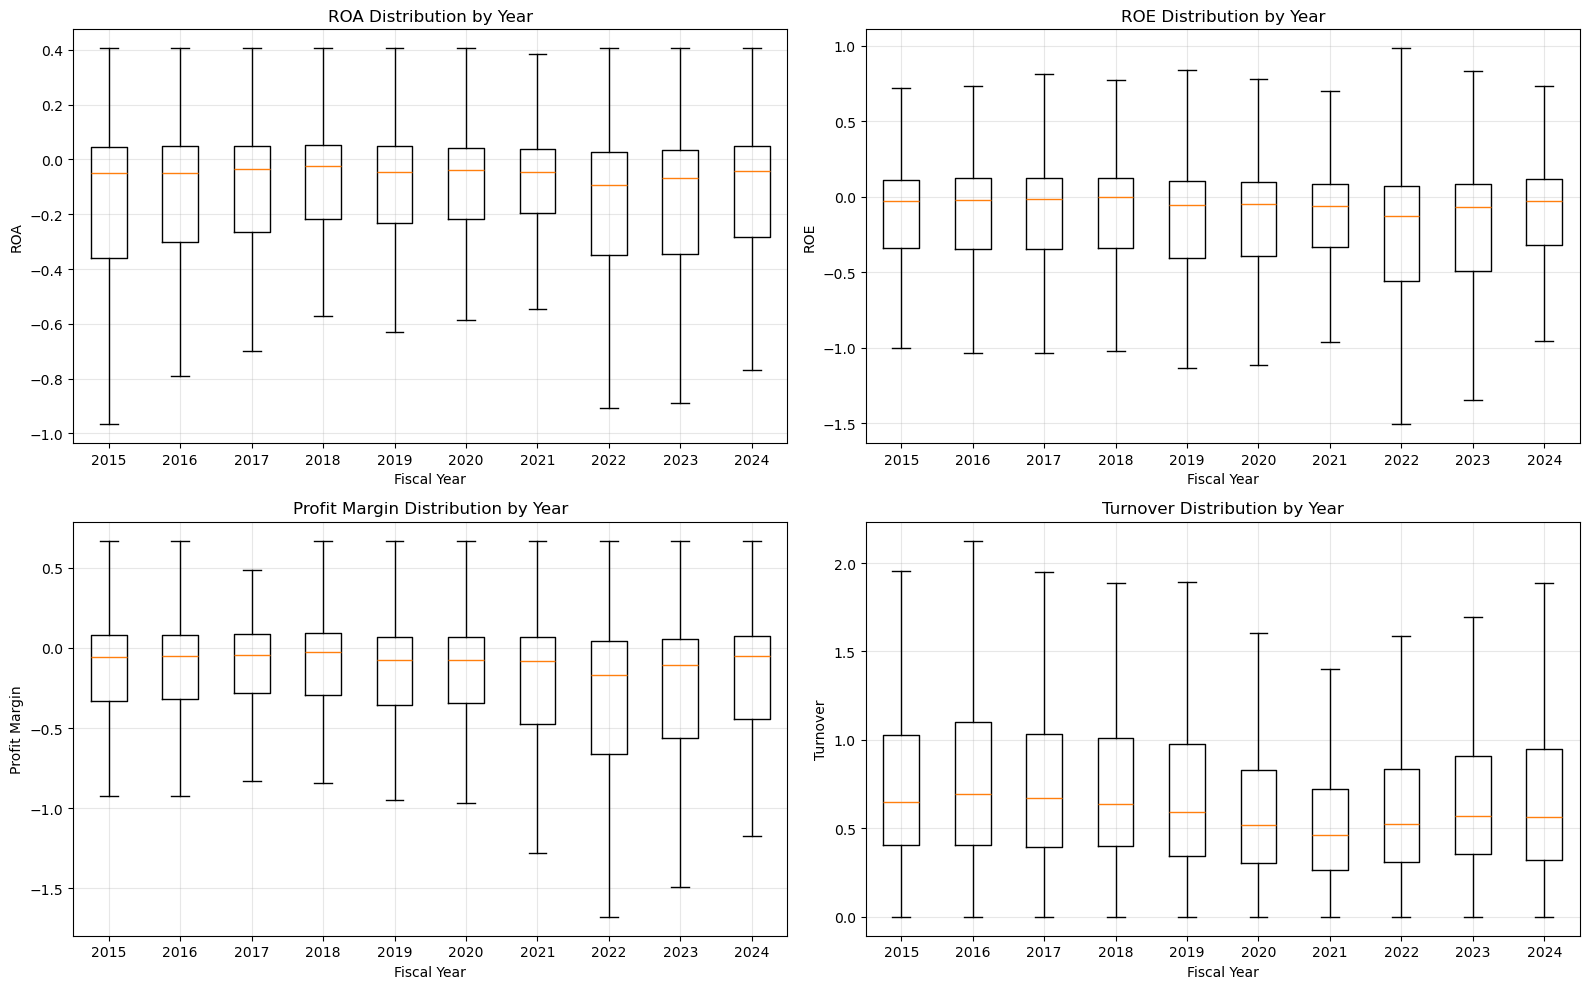

In [22]:
boxplot_metrics = ['roa', 'roe', 'profit_margin', 'turnover']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, boxplot_metrics):
    data_by_year = [
        full_sample.loc[full_sample['fyear'] == year, metric].dropna()
        for year in required_years
    ]
    
    ax.boxplot(data_by_year, tick_labels=required_years, showfliers=False)
    ax.set_title(f'{titles[metric]} Distribution by Year')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel(titles[metric])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

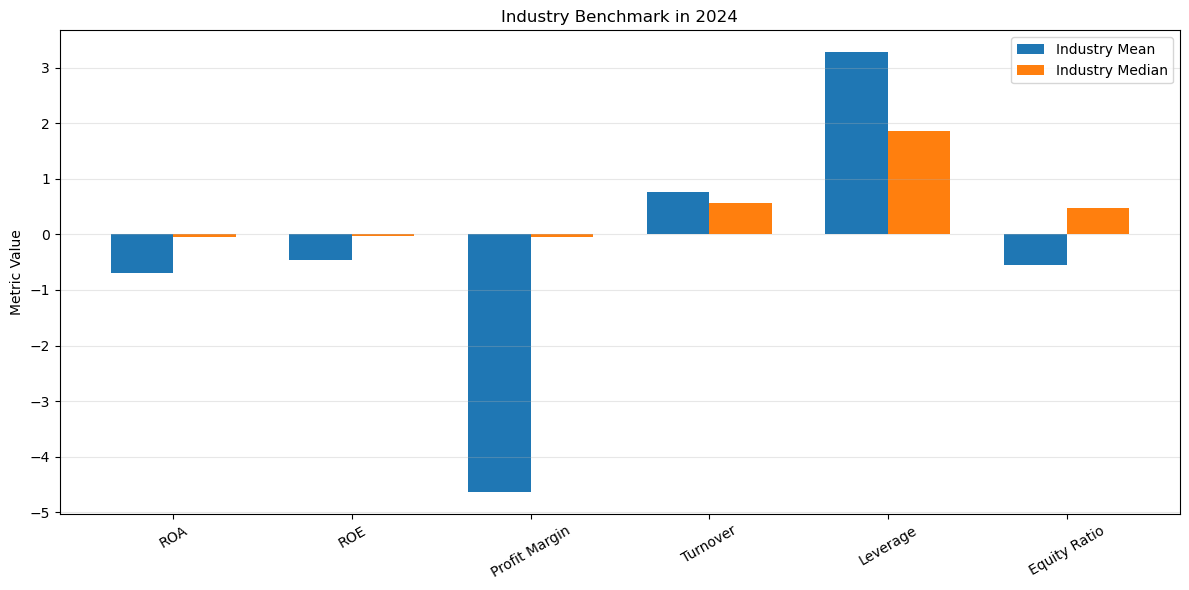

In [23]:
latest_year = analysis_end_year
latest_metrics = ['roa', 'roe', 'profit_margin', 'turnover', 'leverage', 'equity_ratio']

latest_row = industry_benchmark[industry_benchmark['fyear'] == latest_year].iloc[0]

mean_vals = [latest_row[f'{m}_mean'] for m in latest_metrics]
median_vals = [latest_row[f'{m}_median'] for m in latest_metrics]

x = np.arange(len(latest_metrics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, mean_vals, width, label='Industry Mean')
plt.bar(x + width/2, median_vals, width, label='Industry Median')

plt.xticks(x, [titles[m] for m in latest_metrics], rotation=30)
plt.title(f'Industry Benchmark in {latest_year}')
plt.ylabel('Metric Value')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Interactive Company Benchmarking Tool

This section allows a selected company to be compared with the industry benchmark. For each ticker, the notebook produces:

- a firm-level benchmark table by year
- a short diagnostic summary
- time-series comparison charts against the industry mean and median
- a latest-year comparison chart across key metrics

The balanced sample is used here so that long-horizon company comparisons are based on consistent firm-year coverage from 2015 to 2024.

In [25]:
def benchmark_company(ticker_input):
    ticker_input = ticker_input.upper().strip()
    
    company_data = balanced_data[
        balanced_data['ticker'].fillna('').str.upper() == ticker_input
    ].copy()
    
    if company_data.empty:
        print(f"No company found in the balanced benchmark sample for ticker: {ticker_input}")
        print("This usually means the firm does not have complete core metric data for every year from 2015 to 2024.")
        return None, None
    
    company_name = (
        company_data['company_name'].dropna().iloc[0]
        if company_data['company_name'].notna().any()
        else ticker_input
    )
    
    compare_metrics = [
        'roa', 'roe', 'profit_margin', 'turnover',
        'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth'
    ]
    
    company_yearly = (
        company_data.groupby('fyear')[compare_metrics]
        .mean()
        .reset_index()
    )
    
    benchmark_table = company_yearly.merge(
        industry_benchmark,
        on='fyear',
        how='left'
    )
    
    print(f"Benchmarking results for {company_name} ({ticker_input})")
    display(benchmark_table.round(4))
    
    metric_map = {
        'roa': 'ROA',
        'roe': 'ROE',
        'profit_margin': 'Profit Margin',
        'turnover': 'Turnover',
        'leverage': 'Leverage',
        'equity_ratio': 'Equity Ratio',
        'revenue_growth': 'Revenue Growth',
        'asset_growth': 'Asset Growth'
    }
    
    summary_rows = []
    
    for metric in compare_metrics:
        mean_col = f'{metric}_mean'
        median_col = f'{metric}_median'
        
        valid_data = benchmark_table[['fyear', metric, mean_col, median_col]].dropna()
        
        if valid_data.empty:
            continue
        
        above_mean_years = (valid_data[metric] > valid_data[mean_col]).sum()
        above_median_years = (valid_data[metric] > valid_data[median_col]).sum()
        total_years = len(valid_data)
        
        latest_row = valid_data.iloc[-1]
        latest_vs_mean = 'above' if latest_row[metric] > latest_row[mean_col] else 'below'
        latest_vs_median = 'above' if latest_row[metric] > latest_row[median_col] else 'below'
        
        summary_rows.append({
            'Metric': metric_map[metric],
            'Years Above Industry Mean': above_mean_years,
            'Years Above Industry Median': above_median_years,
            'Total Comparable Years': total_years,
            'Latest Year vs Mean': latest_vs_mean,
            'Latest Year vs Median': latest_vs_median
        })
    
    summary_df = pd.DataFrame(summary_rows)
    
    print("\nPerformance Diagnostic Summary")
    display(summary_df)
    
    print("\nInterpretation")
    for _, row in summary_df.iterrows():
        print(
            f"{row['Metric']}: above mean in "
            f"{row['Years Above Industry Mean']}/{row['Total Comparable Years']} years, "
            f"above median in {row['Years Above Industry Median']}/{row['Total Comparable Years']} years, "
            f"latest year vs mean = {row['Latest Year vs Mean']}, "
            f"latest year vs median = {row['Latest Year vs Median']}."
        )
    
    fig, axes = plt.subplots(4, 2, figsize=(16, 18))
    axes = axes.flatten()
    
    for ax, metric in zip(axes, compare_metrics):
        temp = benchmark_table[['fyear', metric, f'{metric}_mean', f'{metric}_median']].dropna()
        
        if temp.empty:
            ax.set_visible(False)
            continue
        
        ax.plot(temp['fyear'], temp[metric], marker='o', label=ticker_input)
        ax.plot(temp['fyear'], temp[f'{metric}_mean'], marker='s', linestyle='--', label='Industry Mean')
        ax.plot(temp['fyear'], temp[f'{metric}_median'], marker='^', linestyle=':', label='Industry Median')
        
        ax.set_title(metric_map[metric], fontsize=12)
        ax.set_xlabel('Fiscal Year')
        ax.set_ylabel(metric_map[metric])
        ax.set_xticks(list(range(analysis_start_year, analysis_end_year + 1)))
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    latest_year = benchmark_table['fyear'].max()
    latest_data = benchmark_table[benchmark_table['fyear'] == latest_year].iloc[0]
    
    latest_metrics = ['roa', 'roe', 'profit_margin', 'turnover', 'leverage', 'equity_ratio']
    company_vals = [latest_data[m] for m in latest_metrics]
    industry_mean_vals = [latest_data[f'{m}_mean'] for m in latest_metrics]
    industry_median_vals = [latest_data[f'{m}_median'] for m in latest_metrics]
    
    x = np.arange(len(latest_metrics))
    width = 0.25
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, company_vals, width, label=ticker_input)
    plt.bar(x, industry_mean_vals, width, label='Industry Mean')
    plt.bar(x + width, industry_median_vals, width, label='Industry Median')
    
    plt.xticks(x, [metric_map[m] for m in latest_metrics], rotation=30)
    plt.title(f'{company_name} vs Industry Benchmark ({latest_year})')
    plt.ylabel('Metric Value')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return benchmark_table, summary_df

Enter a ticker symbol (e.g. MSFT, ADBE):  MSFT


Benchmarking results for MICROSOFT CORP (MSFT)


,fyear,roa,roe,profit_margin,turnover,leverage,equity_ratio,revenue_growth,asset_growth,roa_mean,...,turnover_mean,turnover_median,leverage_mean,leverage_median,equity_ratio_mean,equity_ratio_median,revenue_growth_mean,revenue_growth_median,asset_growth_mean,asset_growth_median
0,2015,0.0692,0.1523,0.1303,0.5310,2.2005,0.4544,0.0825,0.0223,-1.4945,...,0.8369,0.6501,3.3744,1.8534,-1.4983,0.4500,0.2764,0.1106,0.3115,0.0468
1,2016,0.0867,0.2333,0.1969,0.4405,2.6903,0.3717,-0.0883,0.0991,-1.4477,...,0.9109,0.6927,3.4653,1.9411,-1.4085,0.4031,0.2012,0.0950,0.1981,0.0298
2,2017,0.0880,0.2929,0.2357,0.3731,3.3302,0.3003,0.0543,0.2447,-1.3780,...,0.8583,0.6723,3.5350,1.9854,-1.6127,0.4233,0.3724,0.1391,0.4916,0.1066
3,2018,0.0640,0.2003,0.1502,0.4264,3.1293,0.3196,0.2269,0.0737,-1.2574,...,0.8332,0.6403,3.2170,1.9605,-1.0535,0.4448,0.3044,0.1372,0.3557,0.0677
4,2019,0.1369,0.3835,0.3118,0.4392,2.8003,0.3571,0.1403,0.1070,-0.6999,...,0.7925,0.5935,3.6014,2.0430,-0.8069,0.4170,0.3218,0.1394,0.5294,0.1579
5,2020,0.1470,0.3743,0.3096,0.4746,2.5469,0.3926,0.1365,0.0515,-0.6657,...,0.6823,0.5202,3.2021,2.0178,-0.5967,0.4333,0.2918,0.1375,0.6097,0.1584
6,2021,0.1836,0.4315,0.3645,0.5036,2.3508,0.4254,0.1753,0.1078,-0.7062,...,0.5927,0.4646,3.0915,1.8115,-0.4843,0.5034,0.4312,0.2102,0.7687,0.1698
7,2022,0.1994,0.4368,0.3669,0.5434,2.1907,0.4565,0.1796,0.0931,-0.7890,...,0.7136,0.5275,3.5583,1.8664,-0.5759,0.4788,0.3022,0.1320,0.1242,-0.0174
8,2023,0.1756,0.3509,0.3415,0.5144,1.9977,0.5006,0.0688,0.1292,-0.7800,...,0.7564,0.5676,3.4110,1.8742,-0.4735,0.4646,0.2007,0.0830,0.1242,-0.0022
9,2024,0.1721,0.3283,0.3596,0.4786,1.9077,0.5242,0.1567,0.2432,-0.6995,...,0.7524,0.5667,3.2734,1.8670,-0.5438,0.4708,0.1228,0.0666,0.2448,0.0217



Performance Diagnostic Summary


,Metric,Years Above Industry Mean,Years Above Industry Median,Total Comparable Years,Latest Year vs Mean,Latest Year vs Median
0,ROA,10,10,10,above,above
1,ROE,10,10,10,above,above
2,Profit Margin,10,10,10,above,above
3,Turnover,0,2,10,below,below
4,Leverage,0,10,10,below,above
5,Equity Ratio,10,3,10,above,above
6,Revenue Growth,1,4,10,above,above
7,Asset Growth,1,6,10,below,above



Interpretation
ROA: above mean in 10/10 years, above median in 10/10 years, latest year vs mean = above, latest year vs median = above.
ROE: above mean in 10/10 years, above median in 10/10 years, latest year vs mean = above, latest year vs median = above.
Profit Margin: above mean in 10/10 years, above median in 10/10 years, latest year vs mean = above, latest year vs median = above.
Turnover: above mean in 0/10 years, above median in 2/10 years, latest year vs mean = below, latest year vs median = below.
Leverage: above mean in 0/10 years, above median in 10/10 years, latest year vs mean = below, latest year vs median = above.
Equity Ratio: above mean in 10/10 years, above median in 3/10 years, latest year vs mean = above, latest year vs median = above.
Revenue Growth: above mean in 1/10 years, above median in 4/10 years, latest year vs mean = above, latest year vs median = above.
Asset Growth: above mean in 1/10 years, above median in 6/10 years, latest year vs mean = below, latest

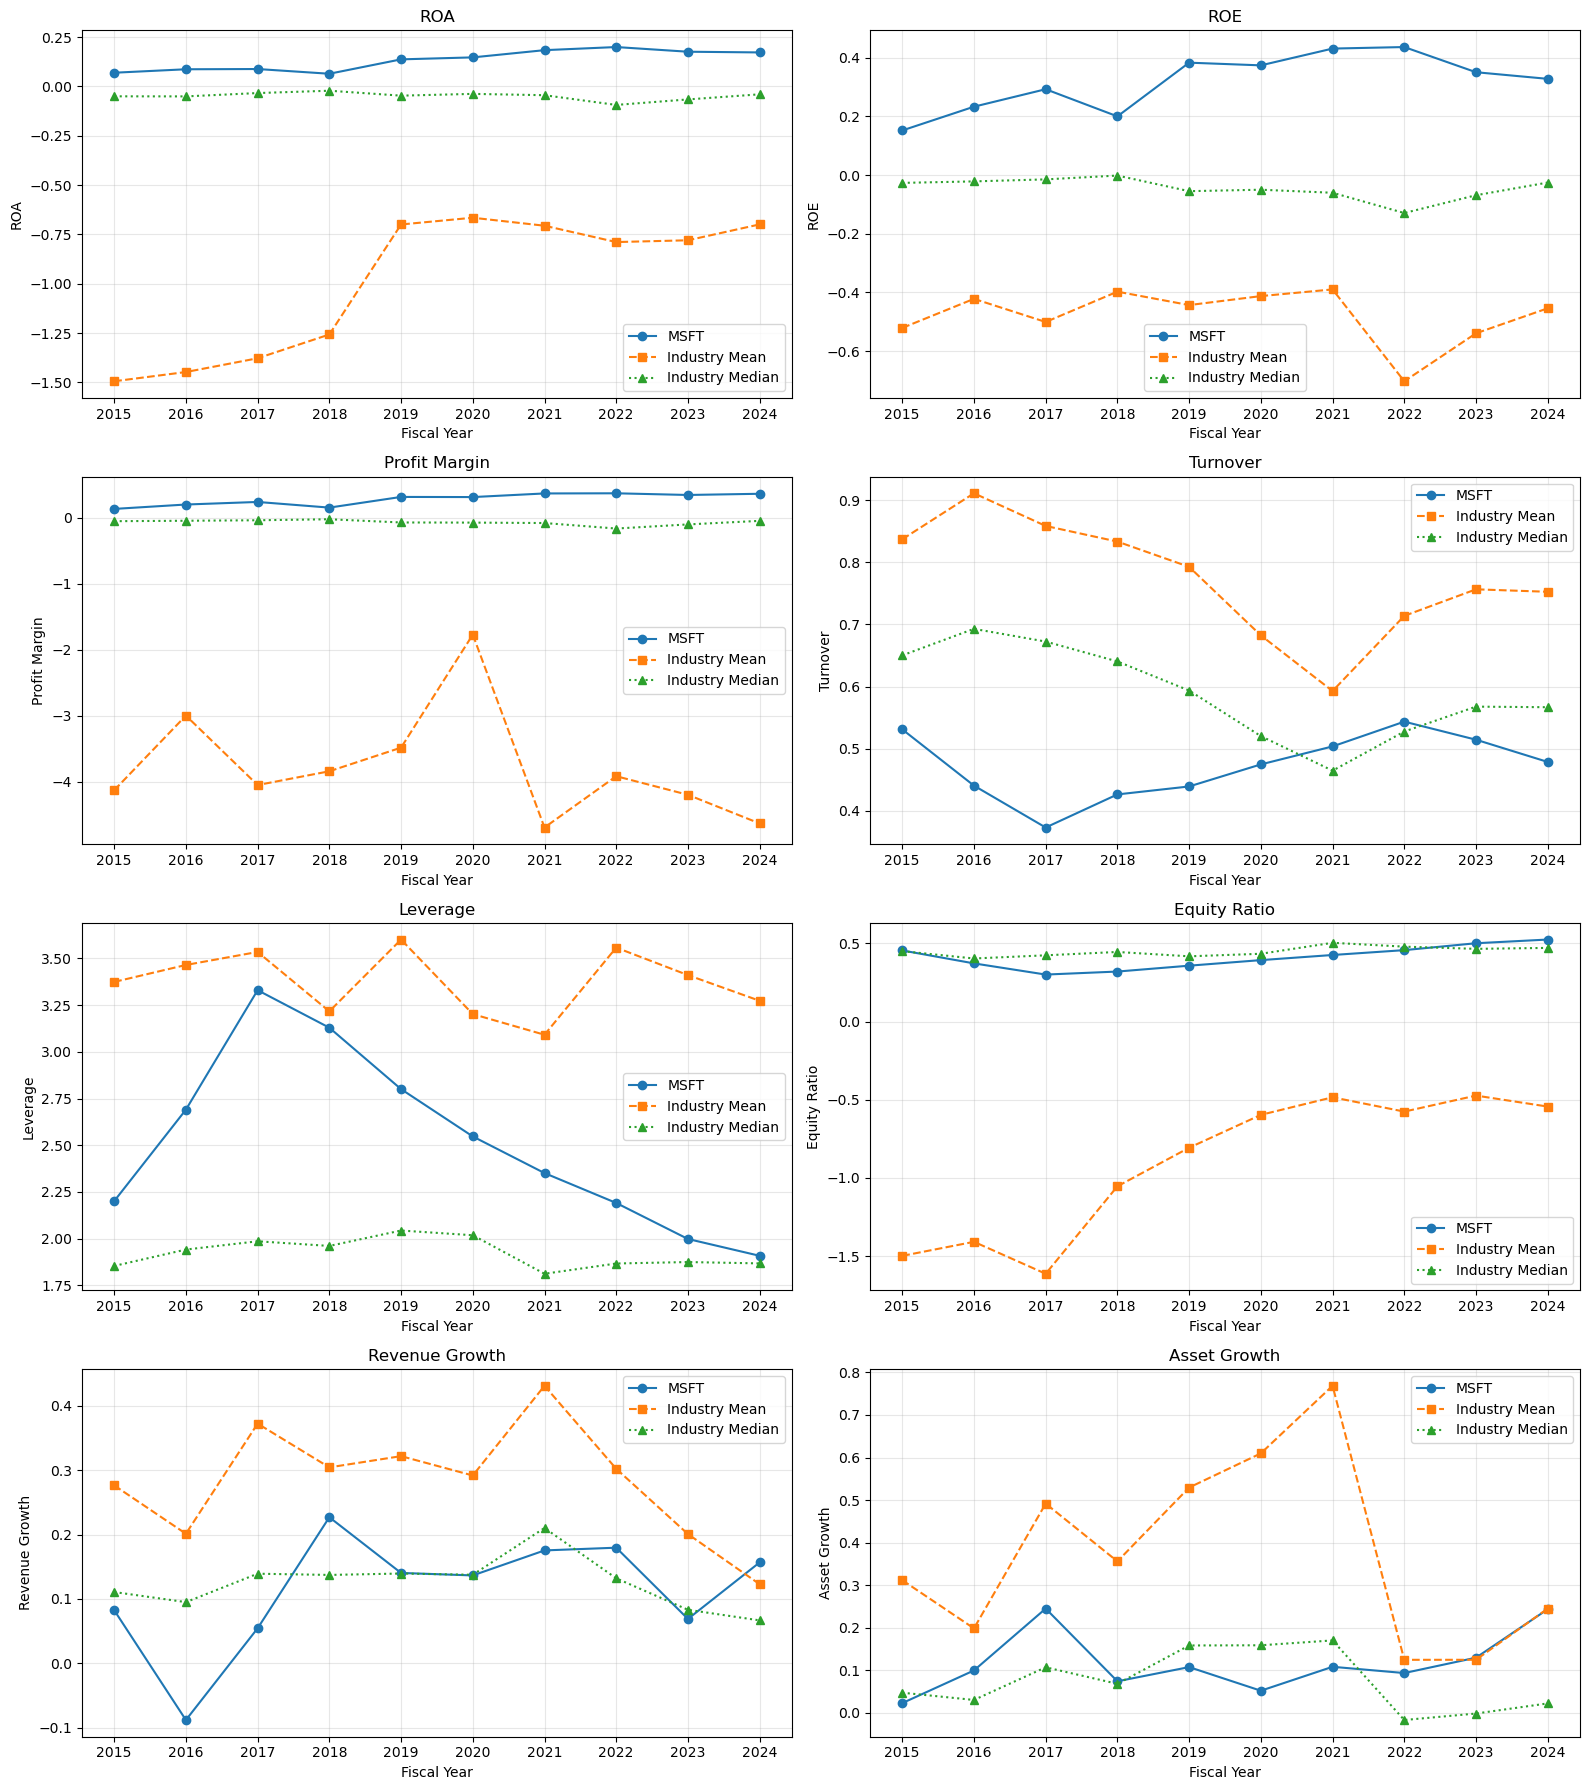

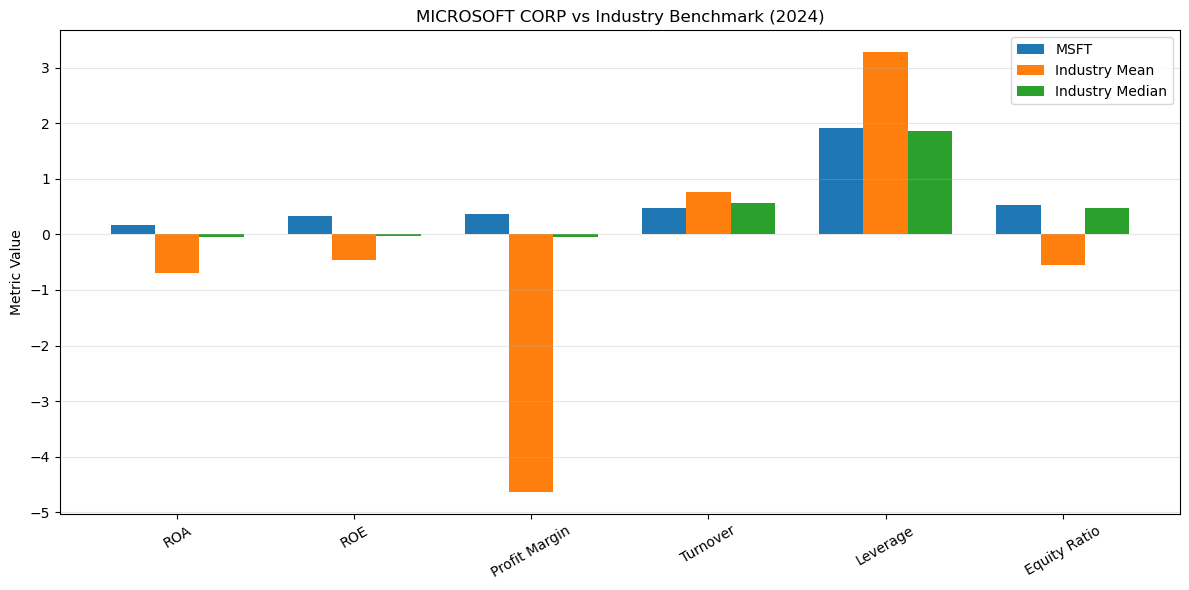

In [26]:
ticker_input = input("Enter a ticker symbol (e.g. MSFT, ADBE): ").upper().strip()

if ticker_input:
    company_result = benchmark_company(ticker_input)

## Conclusion

This project develops a simple interactive benchmarking tool based on WRDS Compustat data for firms in software and related technology services from 2015 to 2024. Using accounting-based performance, capital structure, and growth indicators, the notebook summarises industry-level patterns and then allows a user to compare a selected firm with the industry benchmark over time.

Overall, the project shows how Python and WRDS can be combined to transform raw financial statement data into a practical and user-friendly benchmarking product.

## Limitations

This project has several limitations. First, the industry definition is based on historical SIC codes 7370 to 7379, so the sample may not cover all firms that could be considered part of the broader technology sector. Second, the analysis uses annual accounting data only, which means short-term changes within a year are not captured. Third, some metrics remain unavailable for certain firm-years when the denominator is zero or negative, especially for ROE and leverage. Fourth, winsorization improves stability but may still reduce the visibility of some extreme but economically meaningful observations. Finally, the benchmarking tool compares a selected firm with the industry mean and median, but it does not yet include more advanced features such as peer-group clustering, percentile ranking, or size-based segmentation.

In [28]:
# Export CSV files for Streamlit app

app_cols = [
    'gvkey', 'ticker', 'company_name', 'fyear',
    'roa', 'roe', 'profit_margin', 'turnover',
    'leverage', 'equity_ratio', 'revenue_growth', 'asset_growth'
]

balanced_export = balanced_data[app_cols].copy()
full_export = full_sample[app_cols].copy()
industry_export = industry_benchmark.copy()

# Sort for cleaner app loading
balanced_export = balanced_export.sort_values(['ticker', 'fyear'])
full_export = full_export.sort_values(['ticker', 'fyear'])
industry_export = industry_export.sort_values('fyear')

# Make sure year is integer
balanced_export['fyear'] = balanced_export['fyear'].astype(int)
full_export['fyear'] = full_export['fyear'].astype(int)
industry_export['fyear'] = industry_export['fyear'].astype(int)

# Export
balanced_export.to_csv('balanced_data.csv', index=False)
full_export.to_csv('full_sample.csv', index=False)
industry_export.to_csv('industry_benchmark.csv', index=False)

print("Export completed successfully.")
print("Files created:")
print("- balanced_data.csv")
print("- full_sample.csv")
print("- industry_benchmark.csv")

Export completed successfully.
Files created:
- balanced_data.csv
- full_sample.csv
- industry_benchmark.csv
